# RAKSHAK — SHAP Analysis: Why Does U2R Have So Many False Positives?

The Random Forest, XGBoost, and LightGBM models all clear >99% weighted F1 on CICIDS2017, but
all three struggle specifically on U2R: the soft-voting ensemble catches ~92% of real U2R
attacks (good recall), but only 29% of everything it *flags* as U2R is actually U2R — the rest
is false alarms, overwhelmingly from Normal traffic.

This notebook investigates *why*, using SHAP (SHapley Additive exPlanations) instead of the
plain `.feature_importances_` we already used for feature selection. That gave us "which
features matter on average across the whole forest" — useful, but it can't explain a single
prediction. SHAP can: for one specific flow, it decomposes the model's prediction into exactly
how much each feature pushed the outcome toward or away from each class, based on Shapley
values from cooperative game theory (the same math used to fairly split a payout among players
by individual contribution). The contributions are additive - they sum exactly to the gap
between this prediction and the model's average prediction, so no feature's influence is
over- or under-credited.

**Investigation plan:** rather than a generic random sample (U2R false positives are only
~0.17% of the test set — a random sample would barely contain any), we build a **targeted
comparison**: real U2R flows the Random Forest correctly caught, versus Normal flows it wrongly
flagged as U2R. Comparing their SHAP contributions directly answers "what does the model see in
a false alarm that's different from a genuine attack?"

We use the Random Forest specifically — SHAP's `TreeExplainer` needs a single tree-based model,
not our custom ensemble wrapper, and RF has the most false positives (1,334) to draw from.

## 1. Reconstruct the test set and load the trained model

No retraining here - `split_train_test()` is deterministic (fixed `random_state`), so re-running
it on the same cleaned parquet reproduces the exact same test set `train_model.py` evaluated on.
The scaler is *loaded*, not re-fit (`scaler.transform()`, never `.fit_transform()`) - fitting
it again here would be pointless and risks accidentally diverging from the saved artifact that
detector.py will eventually rely on.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import shap

# Notebooks have no __file__, so PROJECT_ROOT is derived from the working
# directory instead - same pattern as 01_eda.ipynb.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / "src"))

from train_model import (  # noqa: E402
    CICIDS_PATH,
    RF_MODEL_PATH,
    SCALER_PATH,
    SELECTED_FEATURES_PATH,
    load_features_and_target,
    split_train_test,
)

X, y = load_features_and_target(CICIDS_PATH)
X_train, X_test, y_train, y_test = split_train_test(X, y)

with open(SELECTED_FEATURES_PATH) as f:
    selected_features = json.load(f)
X_test = X_test[selected_features]

scaler = joblib.load(SCALER_PATH)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

rf_model = joblib.load(RF_MODEL_PATH)

print(f"X_test_scaled: {X_test_scaled.shape}")
print(f"Model classes: {list(rf_model.classes_)}")

X_test_scaled: (503999, 25)
Model classes: ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']


## 2. Identify the two groups to compare

True positives: real U2R flows the model correctly caught. False positives: real Normal flows
the model wrongly flagged as U2R - the specific problem we're investigating.

In [2]:
y_pred = pd.Series(rf_model.predict(X_test_scaled), index=X_test_scaled.index)

is_true_positive_u2r = (y_test == "U2R") & (y_pred == "U2R")
is_false_positive_u2r = (y_test == "Normal") & (y_pred == "U2R")

print(f"True positive U2R (correctly caught):      {is_true_positive_u2r.sum()}")
print(f"False positive U2R (Normal flagged as U2R): {is_false_positive_u2r.sum()}")

True positive U2R (correctly caught):      369
False positive U2R (Normal flagged as U2R): 1334


## 3. Build a targeted sample

Capped at 200 rows per group - SHAP's `TreeExplainer` is exact and fast for tree ensembles
(no sampling approximation needed the way model-agnostic SHAP methods require), but computing
it for the full 500K-row test set would still be slow and produce an unwieldy amount of output
for a plot to be readable. 200 per group is plenty to see a real pattern.

In [3]:
SHAP_SAMPLE_SIZE_PER_GROUP = 200
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

true_positive_indices = X_test_scaled[is_true_positive_u2r].index
false_positive_indices = X_test_scaled[is_false_positive_u2r].index

tp_sample_indices = (
    true_positive_indices
    if len(true_positive_indices) <= SHAP_SAMPLE_SIZE_PER_GROUP
    else rng.choice(true_positive_indices, size=SHAP_SAMPLE_SIZE_PER_GROUP, replace=False)
)
fp_sample_indices = rng.choice(
    false_positive_indices,
    size=min(SHAP_SAMPLE_SIZE_PER_GROUP, len(false_positive_indices)),
    replace=False,
)

sample_indices = list(tp_sample_indices) + list(fp_sample_indices)
X_shap_sample = X_test_scaled.loc[sample_indices]

print(f"True positive sample: {len(tp_sample_indices)}")
print(f"False positive sample: {len(fp_sample_indices)}")

True positive sample: 200
False positive sample: 200


## 4. Compute SHAP values

`TreeExplainer` computes exact Shapley values for tree ensembles efficiently, by walking the
actual tree structure rather than the brute-force "try every feature subset" approach Shapley
values would otherwise require. Since this is a 5-class problem, it returns contributions for
every class at once - we isolate U2R's column specifically, since that's the prediction we're
investigating.

In [4]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_shap_sample)

u2r_index = list(rf_model.classes_).index("U2R")
u2r_shap_values = shap_values[..., u2r_index]

n_tp = len(tp_sample_indices)
tp_shap = u2r_shap_values[:n_tp]
fp_shap = u2r_shap_values[n_tp:]

print("SHAP values computed. Shape:", u2r_shap_values.shape)

SHAP values computed. Shape: (400, 25)


## 5. Compare feature contributions: real U2R vs. false alarms

How to read a beeswarm plot: each dot is one flow. Its horizontal position is that feature's
SHAP value for U2R (right = pushed the prediction toward U2R, left = pushed away from it). Color
is the feature's actual value for that row (red = high, blue = low). Features are ranked
top-to-bottom by overall impact.

Comparing the two plots directly answers the question this notebook exists to answer: if the
same features drive both groups toward "U2R" in a similar way, the model may be latching onto
something these Normal flows genuinely share with real U2R attacks (a real, if unfortunate,
pattern in the data) rather than a bug.

SHAP summary -- real U2R attacks correctly caught:


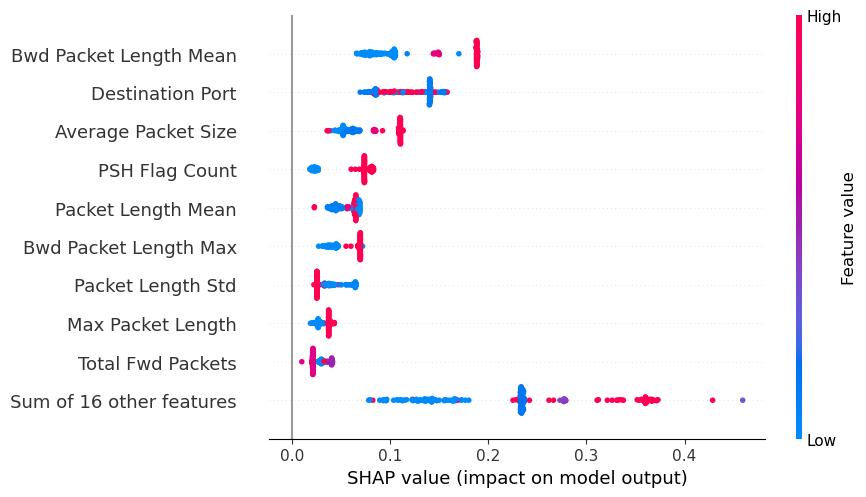

In [5]:
print("SHAP summary -- real U2R attacks correctly caught:")
shap.plots.beeswarm(tp_shap)

SHAP summary -- Normal flows wrongly flagged as U2R:


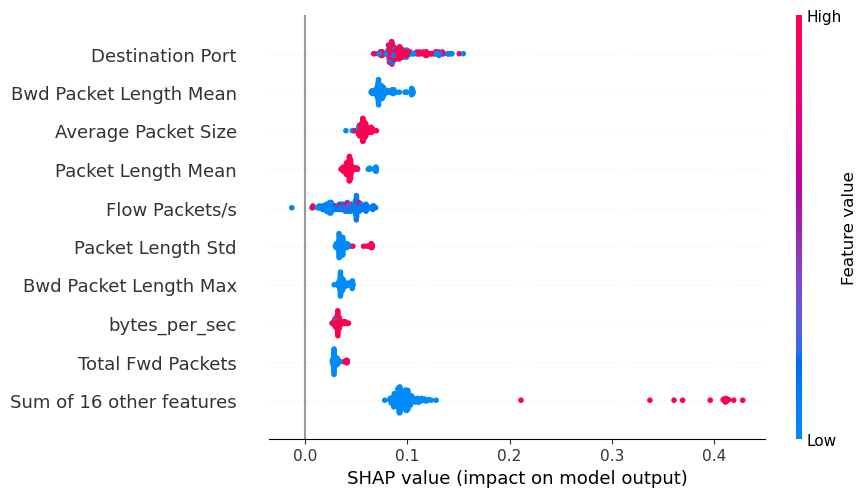

In [6]:
print("SHAP summary -- Normal flows wrongly flagged as U2R:")
shap.plots.beeswarm(fp_shap)

**Observations:** *(rewrite in your own words)*

- Nearly the same features dominate both plots, in nearly the same order: `Bwd Packet Length Mean`, `Destination Port`, `Average Packet Size`, `Packet Length Mean`, `Bwd Packet Length Max` all rank highly in both the true-positive and false-positive groups.
- This is more consistent with "the model is using genuine, if ambiguous, signal" than "the model is reacting to noise" — if the false positives were driven by different/nonsensical features, that would suggest a bug. Instead, the model is using the *same* logic it correctly uses for real U2R.
- One real difference: `PSH Flag Count` shows up meaningfully in the true-positive group but not in the false-positive group's top features — a potential lead for a more discriminating feature.

## 6. Explain one specific false alarm in detail

instructions.md calls this a "force plot" — I'm using `shap.plots.waterfall` instead, the
modern equivalent for explaining a single prediction. Force plots render as interactive
JavaScript, which can be finicky in notebook environments; waterfall plots show the exact same
information (each feature's contribution, stacked from the baseline to the final prediction)
as a plain static image that always renders reliably. Same purpose, more robust rendering.

A single false-positive example -- a real Normal flow the model flagged as U2R:


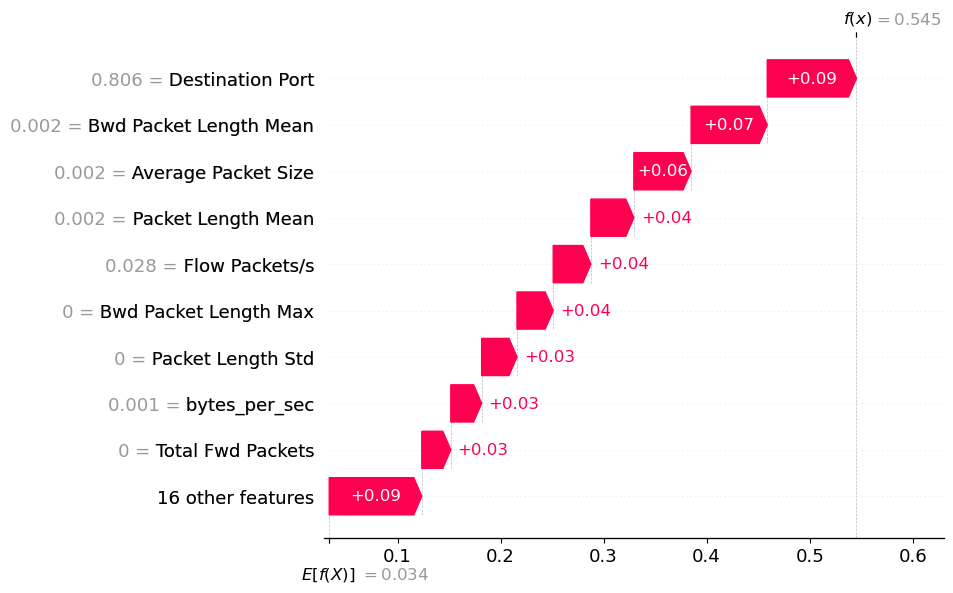

In [7]:
print("A single false-positive example -- a real Normal flow the model flagged as U2R:")
shap.plots.waterfall(fp_shap[0])

A single true-positive example -- a real U2R attack the model correctly caught:


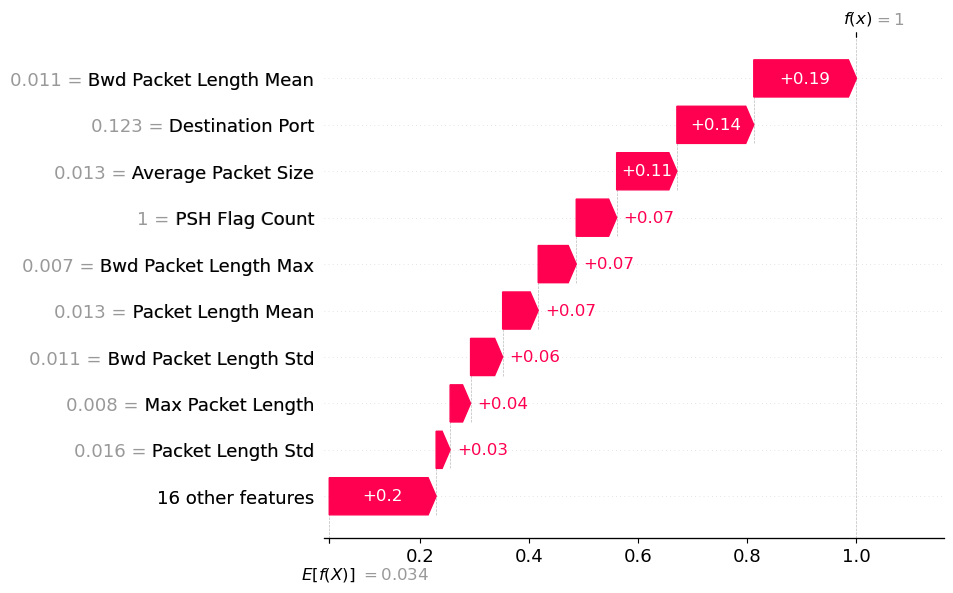

In [8]:
print("A single true-positive example -- a real U2R attack the model correctly caught:")
shap.plots.waterfall(tp_shap[0])

**Observations:** *(rewrite in your own words)*

- The false-positive example: `Bwd Packet Length Mean=0.002`, `Average Packet Size=0.002`, `Packet Length Mean=0.002`, `Total Fwd Packets=0` (all MinMax-scaled) - essentially every packet-size statistic sits at rock bottom. A tiny, minimal, low-volume flow.
- The true-positive (real U2R) example: `Bwd Packet Length Mean=0.011`, `Average Packet Size=0.013`, `Packet Length Mean=0.013` - also tiny, same order of magnitude as the false positive.
- Both examples look like small, sparse, low-data-volume flows. That's plausibly *why* they get confused: U2R attacks in this dataset look like brief, minimal-traffic flows (consistent with what privilege escalation actually looks like on the wire - it's not a bulk transfer), but plenty of genuinely benign traffic (lightweight health checks, brief service calls) produces the same flow-level signature.
- One real difference: the true positive has `PSH Flag Count = 1` (maximum, scaled) contributing +0.07; the false positive doesn't have this flag active at all.

## 7. Conclusion

The false-positive pattern looks more like "the model is picking up on real, if imperfect, signal" than "the model is overreacting to noise" - the same top features drive both correct U2R detections and false alarms, and the false-alarm example shares a genuine structural similarity (small/sparse flow) with real U2R rather than looking like a random misfire.

This connects directly to the Phase 3 SMOTE decision: with only 1,587 real U2R examples, and those examples apparently already clustered around this "small, sparse flow" profile, SMOTE's ~71,000 synthetic examples were interpolated from that same narrow cluster. That likely reinforced "small flow ≈ U2R" as the model's primary shortcut, rather than adding genuine pattern diversity - because there wasn't much real diversity in the original 1,587 to interpolate from in the first place. This isn't a bug in the SMOTE implementation; it's an inherent limit of oversampling when the real minority-class data is itself narrow.